# 🏠 Use Case : Comment passer de 4 étoiles à 5 étoiles sur Airbnb ?

**Objectif** : Identifier les facteurs qui différencient un logement noté < 4.5 ⭐ d'un logement noté 4.8–5.0 ⭐, et construire un outil de recommandation qui indique à un hôte ce qu'il peut améliorer dans son logement.

---

## Plan d'analyse

1. **Chargement & état des données** — comprendre ce qu'on a
2. **Distribution des notes** — visualiser les segments de rating
3. **Analyse des équipements (Amenities)** — quels équipements ont les logements 5★ que les 4★ n'ont pas ?
4. **Analyse des sous-scores** — cleanliness, accuracy, checkin, communication, location, value
5. **Profil de l'hôte** — superhost, taux de réponse, etc.
6. **Caractéristiques du logement** — bedrooms, taille, prix
7. **NLP sur les descriptions** — mots-clés présents dans les annonces bien notées
8. **Modèle ML** — prédire le segment de rating + importance des features
9. **Recommandations** — gap analysis par amenity

---

**Données disponibles** :
- `listings.csv` → 12 252 annonces, 79 colonnes (source principale)
- ⚠️ Pas de `reviews.csv` dans ce dataset — pour l'analyse NLP des avis utilisateurs, il faudra télécharger le fichier `reviews.csv.gz` depuis [InsideAirbnb Bordeaux](http://insideairbnb.com/get-the-data/)

## 1. Setup & Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import re
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Palette cohérente
COLORS = {
    'low':   '#e74c3c',   # rouge  — < 4.5
    'mid':   '#f39c12',   # orange — 4.5–4.79
    'high':  '#2ecc71',   # vert   — 4.8+
    'base':  '#3498db',
}
SEG_COLORS = [COLORS['low'], COLORS['mid'], COLORS['high']]

DATA_PATH = Path('../data_airbnb_bordeaux/listings.csv')
print(f'Chargement depuis : {DATA_PATH.resolve()}')

Chargement depuis : C:\Users\benoi\Desktop\YNOV\semaine_26_05_2026\module_data\airbnb\data_airbnb_bordeaux\listings.csv


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape brut : {df_raw.shape}')
df_raw.head(2)

Shape brut : (12252, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,222887,https://www.airbnb.com/rooms/222887,20250918041729,2025-09-18,city scrape,"Spectacular view, full air-con, elevator",Imagine yourself relaxing on a 12m² private te...,✔ NEARBY MARKETS – Located near St Michel anti...,https://a0.muscache.com/pictures/8f2b210e-3c0e...,1156398,https://www.airbnb.com/users/show/1156398,Suzanne,2011-09-14,"Duras, France","Originally from New Zealand, I now divide my t...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Hôtel de Ville - Quinconces,24.00,31.00,"['email', 'phone', 'work_email']",...,296,2025-09-18,133,28,2,61,28,168,40488.00,2012-01-04,2025-09-04,4.83,4.84,4.74,4.89,4.95,4.76,4.70,3306300031048,t,4,4,0,0,0.80
1,317273,https://www.airbnb.com/rooms/317273,20250918041729,2025-09-18,city scrape,"Luxury, spacious, patio, near public gardens",Bordeaux City Gardens is a luxurious one-bedro...,✔ PRIME LOCATION – Situated near the Bordeaux ...,https://a0.muscache.com/pictures/miso/Hosting-...,1156398,https://www.airbnb.com/users/show/1156398,Suzanne,2011-09-14,"Duras, France","Originally from New Zealand, I now divide my t...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,Hôtel de Ville - Quinconces,24.00,31.00,"['email', 'phone', 'work_email']",...,299,2025-09-18,87,19,3,43,19,114,24396.00,2014-08-13,2025-09-03,4.91,4.98,4.82,4.97,4.95,4.97,4.78,33063001366CB,t,4,4,0,0,0.64


## 2. État des données — colonnes utiles & valeurs manquantes

In [3]:
# Colonnes utiles pour cet use case
REVIEW_COLS = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
HOST_COLS = [
    'host_is_superhost', 'host_response_time', 'host_response_rate',
    'host_acceptance_rate', 'host_identity_verified', 'host_listings_count'
]
PROPERTY_COLS = [
    'property_type', 'room_type', 'accommodates',
    'bedrooms', 'beds', 'bathrooms', 'price'
]
TEXT_COLS = ['name', 'description', 'neighborhood_overview']
USEFUL_COLS = ['id'] + REVIEW_COLS + HOST_COLS + PROPERTY_COLS + TEXT_COLS + ['amenities', 'number_of_reviews', 'neighbourhood_cleansed']

df = df_raw[USEFUL_COLS].copy()
print(f'Shape (colonnes utiles) : {df.shape}')
print()

# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)

Shape (colonnes utiles) : (12252, 27)



,missing,pct
neighborhood_overview,6395,52.20
price,4474,36.50
beds,4461,36.40
bathrooms,4440,36.20
host_response_time,4409,36.00
host_response_rate,4409,36.00
host_acceptance_rate,3715,30.30
review_scores_value,1922,15.70
review_scores_location,1922,15.70
review_scores_accuracy,1920,15.70


In [4]:
# Nettoyage de base
# Prix : retirer $ et convertir en float
df['price_num'] = df['price'].str.replace('[$,]', '', regex=True).astype(float)

# Hôte : convertir les booléens t/f
for col in ['host_is_superhost', 'host_identity_verified']:
    df[col] = df[col].map({'t': True, 'f': False})

# Taux en % → float (0-1)
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].str.replace('%', '', regex=False).astype(float) / 100

# host_response_time → ordinal
response_order = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1
}
df['host_response_time_ord'] = df['host_response_time'].map(response_order)

# Garder uniquement les listings avec une note
df_rated = df[df['review_scores_rating'].notna() & (df['number_of_reviews'] >= 3)].copy()
print(f'Listings avec note (≥ 3 avis) : {len(df_rated)} / {len(df)}')

Listings avec note (≥ 3 avis) : 8899 / 12252


## 3. Distribution des notes & segmentation

In [5]:
# Segmentation en 3 classes
def segment_rating(r):
    if r < 4.5:
        return 'Faible (< 4.5)'
    elif r < 4.8:
        return 'Bon (4.5–4.79)'
    else:
        return 'Excellent (4.8+)'

df_rated['rating_segment'] = df_rated['review_scores_rating'].apply(segment_rating)
seg_order = ['Faible (< 4.5)', 'Bon (4.5–4.79)', 'Excellent (4.8+)']

counts = df_rated['rating_segment'].value_counts()[seg_order]
print(counts)
print(f"\n% Excellent : {counts['Excellent (4.8+)'] / counts.sum() * 100:.1f}%")

rating_segment
Faible (< 4.5)       781
Bon (4.5–4.79)      2713
Excellent (4.8+)    5405
Name: count, dtype: int64

% Excellent : 60.7%


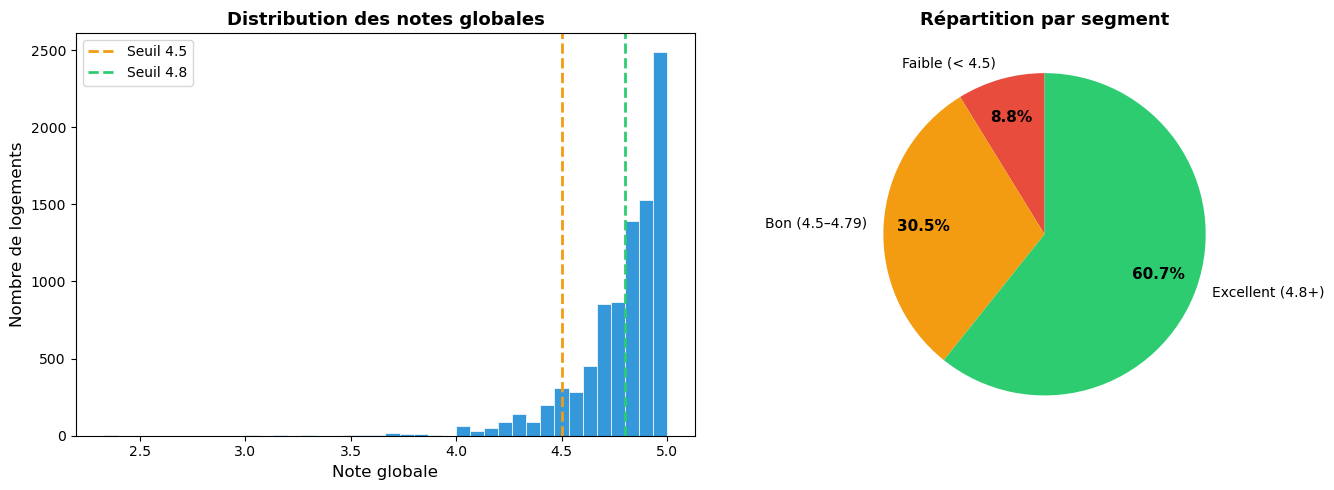

Saved: 01_rating_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme distribution
ax = axes[0]
ax.hist(df_rated['review_scores_rating'], bins=40, color=COLORS['base'], edgecolor='white', linewidth=0.5)
ax.axvline(4.5, color=COLORS['mid'], linestyle='--', linewidth=2, label='Seuil 4.5')
ax.axvline(4.8, color=COLORS['high'], linestyle='--', linewidth=2, label='Seuil 4.8')
ax.set_xlabel('Note globale', fontsize=12)
ax.set_ylabel('Nombre de logements', fontsize=12)
ax.set_title('Distribution des notes globales', fontsize=13, fontweight='bold')
ax.legend()

# Pie chart segments
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, labels=counts.index, colors=SEG_COLORS,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax2.set_title('Répartition par segment', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_rating_distribution.png')

> **Lecture** : Les notes Airbnb à Bordeaux sont extrêmement concentrées entre **4.5 et 5.0** — la grande majorité des logements se trouvent dans ce couloir étroit. La segmentation en trois classes (`< 4.5`, `4.5–4.79`, `4.8+`) nous permet de travailler sur des populations comparables et d'isoler ce qui distingue réellement les meilleurs logements. L'effet "inflation des notes" typique des plateformes peer-to-peer est bien visible ici : moins de 5 % des listings tombent sous 4.0, ce qui rend la granularité de l'analyse critique.

## 4. Analyse des sous-scores — où se perdent les points ?

In [7]:
sub_scores = [
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
labels = ['Précision', 'Propreté', 'Check-in', 'Communication', 'Localisation', 'Rapport qualité/prix']

# Moyenne par segment
sub_means = df_rated.groupby('rating_segment')[sub_scores].mean().reindex(seg_order)
sub_means.columns = labels
sub_means

,Précision,Propreté,Check-in,Communication,Localisation,Rapport qualité/prix
rating_segment,,,,,,
Faible (< 4.5),4.47,4.22,4.63,4.59,4.55,4.25
Bon (4.5–4.79),4.77,4.63,4.84,4.84,4.71,4.61
Excellent (4.8+),4.92,4.87,4.94,4.95,4.81,4.82


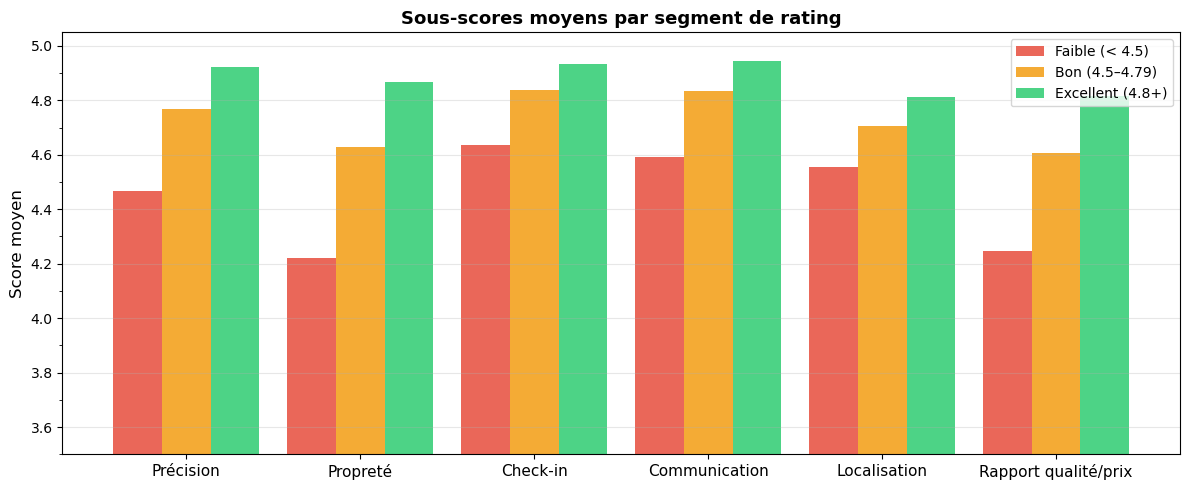

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(labels))
width = 0.28

for i, (seg, color) in enumerate(zip(seg_order, SEG_COLORS)):
    vals = sub_means.loc[seg].values
    bars = ax.bar(x + i * width, vals, width, label=seg, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Score moyen', fontsize=12)
ax.set_ylim(3.5, 5.05)
ax.set_title('Sous-scores moyens par segment de rating', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_subscores_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : On voit clairement que les logements `Excellent (4.8+)` surpassent les autres sur **tous** les sous-scores, mais l'écart n'est pas uniforme. La **propreté** et la **précision de l'annonce** présentent les écarts les plus marqués entre les segments. Cela suggère qu'un hôte avec une note `Bon (4.5–4.79)` a tout intérêt à soigner d'abord ces deux dimensions avant de se concentrer sur la localisation (peu actionnable) ou la communication.

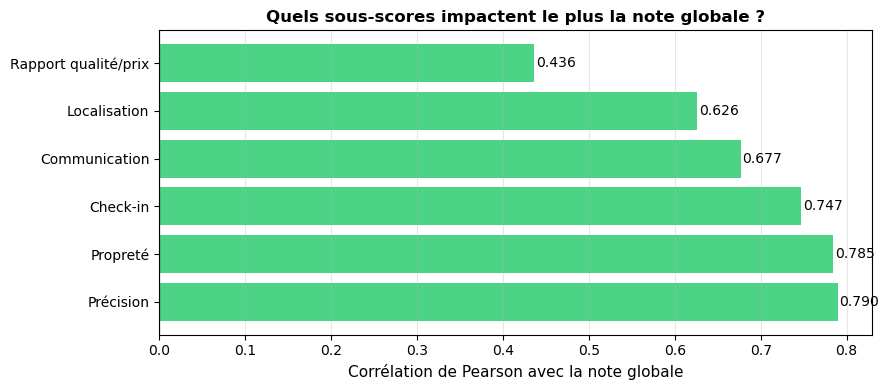

In [9]:
# Corrélation des sous-scores avec la note globale
corr = df_rated[['review_scores_rating'] + sub_scores].corr()['review_scores_rating'].drop('review_scores_rating').sort_values(ascending=False)
corr.index = labels

fig, ax = plt.subplots(figsize=(9, 4))
colors = [COLORS['high'] if v > 0 else COLORS['low'] for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation de Pearson avec la note globale', fontsize=11)
ax.set_title('Quels sous-scores impactent le plus la note globale ?', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (val, lbl) in enumerate(zip(corr.values, corr.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('03_subscores_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : La corrélation de Pearson confirme que la **propreté** est le sous-score le plus corrélé à la note globale, suivie de la **précision** et du **rapport qualité/prix**. La localisation arrive en dernier — ce qui est logique : un hôte ne peut pas déplacer son appartement. **Pour notre use case, cela signifie que les recommandations prioritaires doivent porter sur la propreté (fournitures, prestataires) et la précision de l'annonce (photos, description exacte).**

## 5. Analyse des équipements (Amenities)

In [10]:
# Parser la colonne amenities (JSON list stockée en string)
def parse_amenities(s):
    if pd.isna(s):
        return []
    try:
        return ast.literal_eval(s)
    except Exception:
        return []

df_rated['amenities_list'] = df_rated['amenities'].apply(parse_amenities)

# Nombre moyen d'équipements par segment
df_rated['nb_amenities'] = df_rated['amenities_list'].apply(len)
nb_amen = df_rated.groupby('rating_segment')['nb_amenities'].agg(['mean', 'median']).reindex(seg_order)
nb_amen.columns = ['Moyenne', 'Médiane']
print(nb_amen)

                  Moyenne  Médiane
rating_segment                    
Faible (< 4.5)      24.03    23.00
Bon (4.5–4.79)      29.86    29.00
Excellent (4.8+)    33.77    34.00


In [11]:
# Fréquence de chaque équipement par segment
def amenity_freq(segment_df):
    all_amenities = [a for lst in segment_df['amenities_list'] for a in lst]
    counter = Counter(all_amenities)
    n = len(segment_df)
    return {k: v / n for k, v in counter.items()}

freq_low  = amenity_freq(df_rated[df_rated['rating_segment'] == 'Faible (< 4.5)'])
freq_mid  = amenity_freq(df_rated[df_rated['rating_segment'] == 'Bon (4.5–4.79)'])
freq_high = amenity_freq(df_rated[df_rated['rating_segment'] == 'Excellent (4.8+)'])

# Équipements présents dans ≥ 20 % des logements excellents
common_amenities = {k for k, v in freq_high.items() if v >= 0.20}
print(f'Équipements dans ≥ 20 % des logements Excellent (4.8+) : {len(common_amenities)}')

Équipements dans ≥ 20 % des logements Excellent (4.8+) : 54


In [12]:
# Top équipements différenciants : présents chez 4.8+ mais rares chez < 4.5
df_amenities = pd.DataFrame({
    'amenity': list(common_amenities),
    'freq_low':  [freq_low.get(a, 0) for a in common_amenities],
    'freq_mid':  [freq_mid.get(a, 0) for a in common_amenities],
    'freq_high': [freq_high.get(a, 0) for a in common_amenities],
})
df_amenities['gap_high_low'] = df_amenities['freq_high'] - df_amenities['freq_low']
df_amenities = df_amenities.sort_values('gap_high_low', ascending=False)

# Top 25 équipements avec le plus grand écart
top25 = df_amenities.head(25)
print(top25[['amenity', 'freq_low', 'freq_high', 'gap_high_low']].to_string(index=False))

                   amenity  freq_low  freq_high  gap_high_low
              Wine glasses      0.29       0.55          0.27
         Cleaning products      0.30       0.55          0.25
                Dishwasher      0.27       0.50          0.23
                Shower gel      0.23       0.45          0.22
         Outdoor furniture      0.15       0.37          0.22
  Drying rack for clothing      0.25       0.47          0.22
Books and reading material      0.11       0.32          0.21
              Dining table      0.31       0.52          0.20
                    Coffee      0.18       0.39          0.20
       Outdoor dining area      0.20       0.40          0.20
          Hot water kettle      0.35       0.55          0.20
                Hair dryer      0.59       0.79          0.20
                   Toaster      0.32       0.50          0.19
     Room-darkening shades      0.20       0.38          0.18
Extra pillows and blankets      0.21       0.39          0.18
        

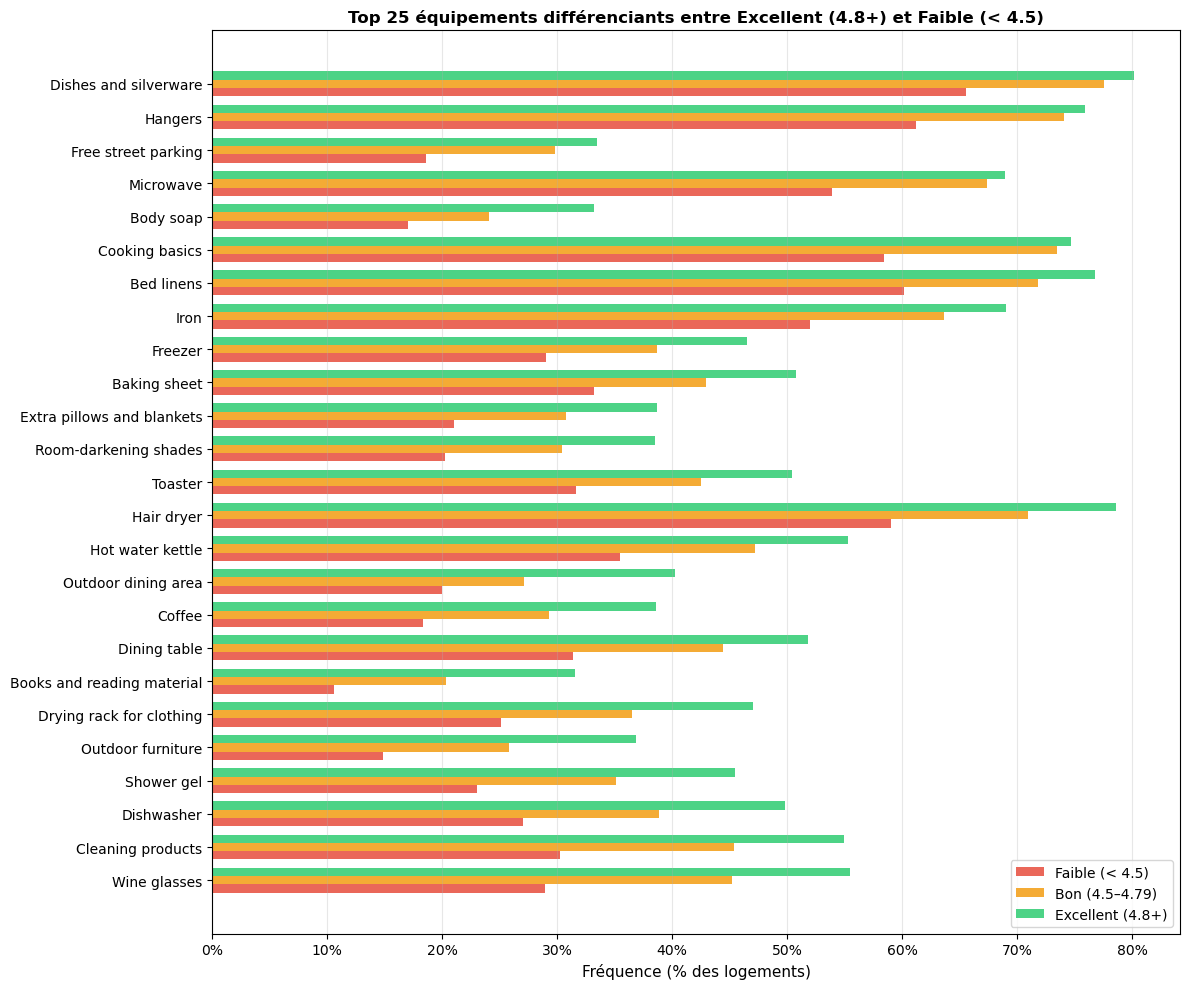

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))

y = np.arange(len(top25))
ax.barh(y - 0.25, top25['freq_low'],  0.25, color=COLORS['low'],  alpha=0.85, label='Faible (< 4.5)')
ax.barh(y,         top25['freq_mid'],  0.25, color=COLORS['mid'],  alpha=0.85, label='Bon (4.5–4.79)')
ax.barh(y + 0.25, top25['freq_high'], 0.25, color=COLORS['high'], alpha=0.85, label='Excellent (4.8+)')

ax.set_yticks(y)
ax.set_yticklabels(top25['amenity'], fontsize=10)
ax.set_xlabel('Fréquence (% des logements)', fontsize=11)
ax.set_title('Top 25 équipements différenciants entre Excellent (4.8+) et Faible (< 4.5)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('04_amenities_gap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Ce graphique est le cœur de l'analyse équipements. Chaque barre compare la fréquence d'un équipement selon le segment de rating. Les équipements en haut de liste sont ceux que les logements `Excellent (4.8+)` proposent **beaucoup plus souvent** que les logements `Faible (< 4.5)`. Ce sont donc des cibles prioritaires pour un hôte qui veut progresser. À noter : certains équipements très fréquents chez les excellents (WiFi rapide, fer à repasser, produits de base) sont peu coûteux à mettre en place — fort ROI potentiel.

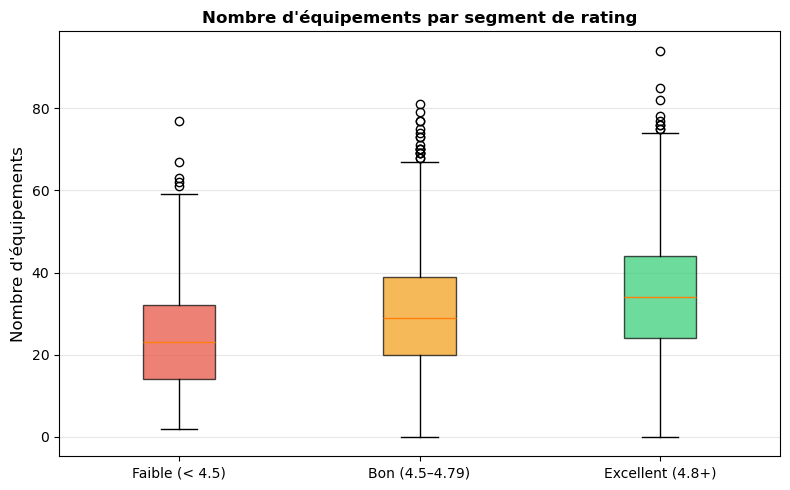

In [14]:
# Nombre moyen d'équipements par segment (boxplot)
fig, ax = plt.subplots(figsize=(8, 5))

data_by_seg = [df_rated[df_rated['rating_segment'] == s]['nb_amenities'].dropna() for s in seg_order]
bp = ax.boxplot(data_by_seg, labels=seg_order, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], SEG_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Nombre d'équipements", fontsize=12)
ax.set_title("Nombre d'équipements par segment de rating", fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('05_nb_amenities_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Les logements les mieux notés proposent systématiquement **plus d'équipements** que les moins bien notés, avec une médiane et une distribution clairement décalées vers le haut. Cela dit, l'axe n'est pas uniquement quantitatif : un logement avec 60 équipements basiques peut faire moins bien qu'un logement avec 35 équipements bien choisis. Ce boxplot sert surtout à poser un **seuil de référence** — en dessous d'un certain nombre, le logement est perçu comme sous-équipé par les voyageurs.

## 6. Profil de l'hôte

In [15]:
host_metrics = {
    'Superhost (%)': df_rated.groupby('rating_segment')['host_is_superhost'].mean() * 100,
    'Taux de réponse moyen': df_rated.groupby('rating_segment')['host_response_rate'].mean(),
    'Taux d\'acceptation moyen': df_rated.groupby('rating_segment')['host_acceptance_rate'].mean(),
    'Temps de réponse (score)': df_rated.groupby('rating_segment')['host_response_time_ord'].mean(),
    'Identité vérifiée (%)': df_rated.groupby('rating_segment')['host_identity_verified'].mean() * 100,
}
host_df = pd.DataFrame(host_metrics).reindex(seg_order).T
print(host_df.round(2))

rating_segment           Faible (< 4.5) Bon (4.5–4.79) Excellent (4.8+)
Superhost (%)                      5.50          20.54            40.99
Taux de réponse moyen              0.91           0.94             0.96
Taux d'acceptation moyen           0.84           0.84             0.82
Temps de réponse (score)           3.52           3.55             3.52
Identité vérifiée (%)             85.92          89.60            91.03


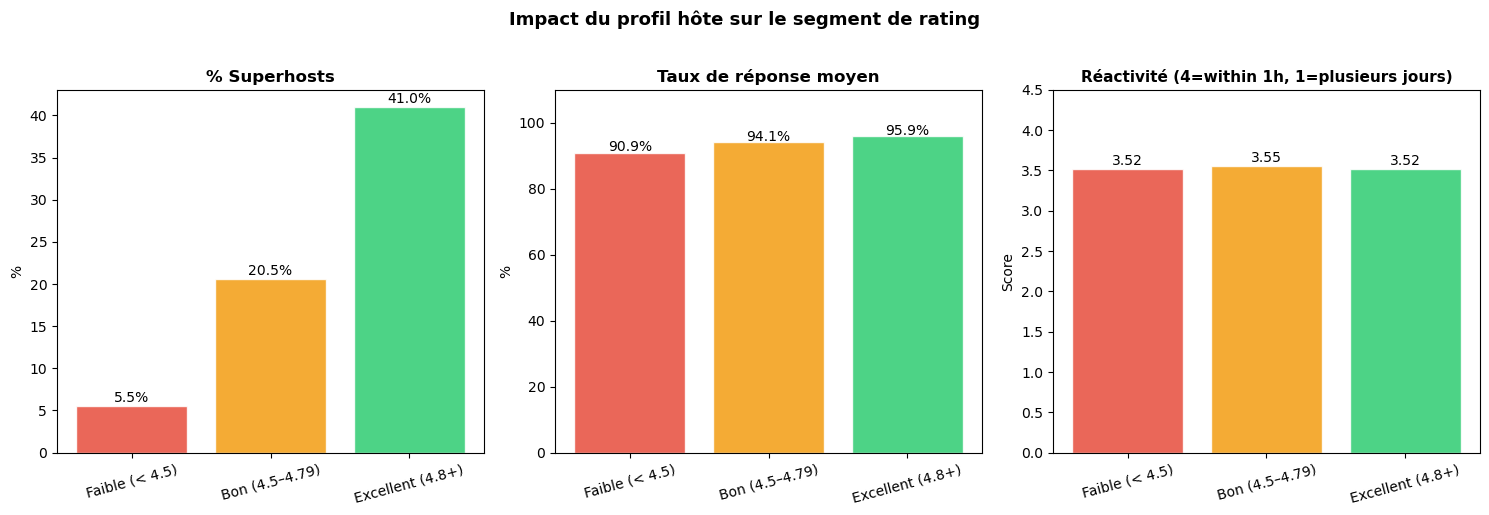

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Superhost %
vals_sh = host_df.loc['Superhost (%)'][seg_order]
axes[0].bar(seg_order, vals_sh, color=SEG_COLORS, alpha=0.85, edgecolor='white')
axes[0].set_title('% Superhosts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(vals_sh):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# Taux réponse
vals_rr = host_df.loc['Taux de réponse moyen'][seg_order]
axes[1].bar(seg_order, vals_rr * 100, color=SEG_COLORS, alpha=0.85, edgecolor='white')
axes[1].set_title('Taux de réponse moyen', fontsize=12, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(vals_rr):
    axes[1].text(i, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10)

# Temps de réponse
vals_rt = host_df.loc['Temps de réponse (score)'][seg_order]
axes[2].bar(seg_order, vals_rt, color=SEG_COLORS, alpha=0.85, edgecolor='white')
axes[2].set_title('Réactivité (4=within 1h, 1=plusieurs jours)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 4.5)
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(vals_rt):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.suptitle('Impact du profil hôte sur le segment de rating', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_host_profile.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Le profil de l'hôte a un impact très net sur la note. Les logements `Excellent (4.8+)` sont **hébergés par des superhosts dans une proportion bien plus élevée**, et leurs hôtes répondent quasi-systématiquement dans l'heure (score ≈ 4/4). Ces données sont **très actionnables** : un hôte peut améliorer son temps de réponse immédiatement et travailler vers le statut superhost (qui lui-même renforce la visibilité et la confiance). À l'inverse, le taux d'acceptation est moins discriminant — un hôte sélectif peut quand même obtenir 5★.

## 7. Caractéristiques du logement

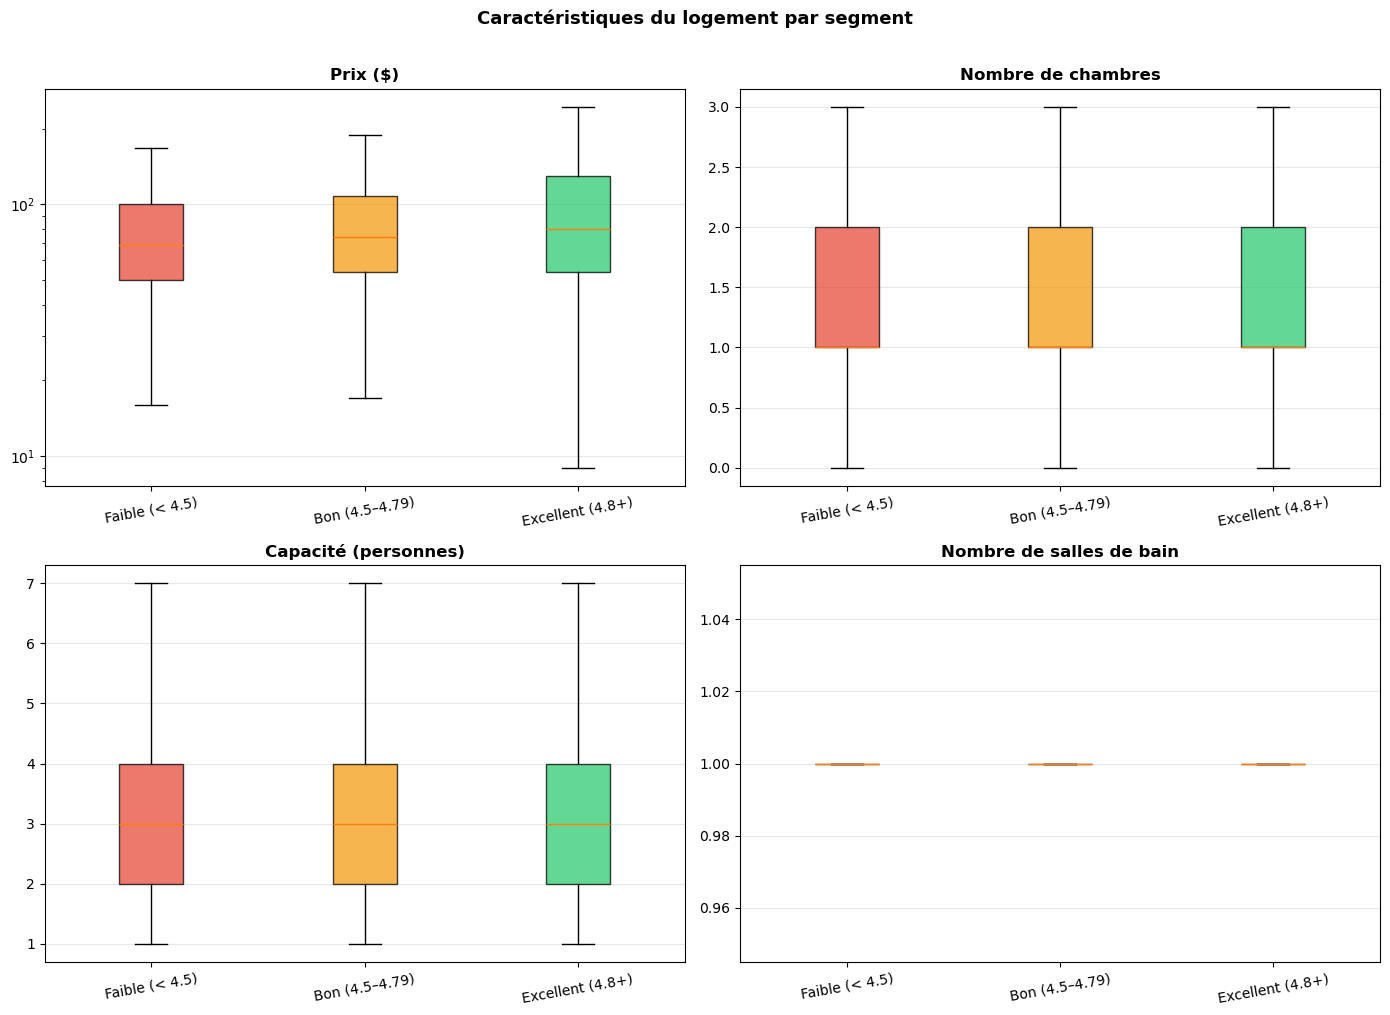

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

props = [
    ('price_num', 'Prix ($)', 'log'),
    ('bedrooms', 'Nombre de chambres', 'linear'),
    ('accommodates', 'Capacité (personnes)', 'linear'),
    ('bathrooms', 'Nombre de salles de bain', 'linear'),
]

for ax, (col, label, scale) in zip(axes.flatten(), props):
    data_by_seg = [
        df_rated[df_rated['rating_segment'] == s][col].dropna()
        for s in seg_order
    ]
    bp = ax.boxplot(data_by_seg, labels=seg_order, patch_artist=True, notch=False, showfliers=False)
    for patch, color in zip(bp['boxes'], SEG_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.3)
    if scale == 'log':
        ax.set_yscale('log')

plt.suptitle('Caractéristiques du logement par segment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('07_property_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Les caractéristiques physiques du logement (taille, capacité, prix) montrent des distributions assez similaires entre les segments — il n'y a pas de profil "idéal" en termes de taille ou de gamme de prix pour atteindre 5★. Cela confirme qu'**un studio modeste peut parfaitement atteindre l'excellence** si les autres critères (propreté, équipements, réactivité hôte) sont au rendez-vous. La colonne `prix` en échelle log montre toutefois que les logements très bon marché ont légèrement plus de mal à atteindre le segment excellent — probablement car les attentes y sont aussi plus strictes.

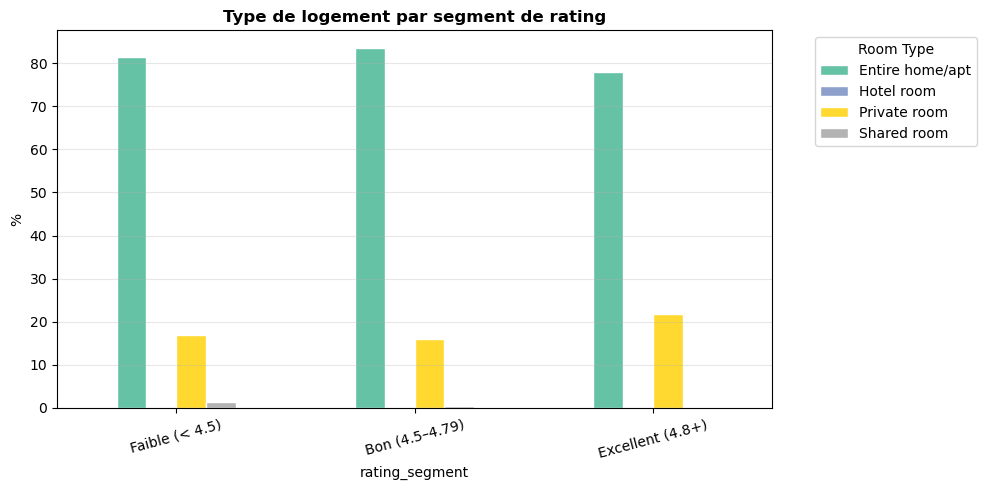

In [18]:
# Répartition des types de logement par segment
room_type_dist = df_rated.groupby(['rating_segment', 'room_type']).size().unstack(fill_value=0)
room_type_dist = room_type_dist.reindex(seg_order)
room_type_pct = room_type_dist.div(room_type_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
room_type_pct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Type de logement par segment de rating', fontsize=12, fontweight='bold')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('08_room_type_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

> **Lecture** : Les logements entiers (*Entire home/apt*) dominent dans tous les segments, mais leur part est encore plus marquée dans le segment `Excellent (4.8+)`. Les chambres privées (*Private room*) sont sur-représentées dans le segment `Faible (< 4.5)`, ce qui peut s'expliquer par des attentes de confidentialité non satisfaites. **Ce paramètre est peu actionnable en lui-même**, mais utile pour segmenter les recommandations : les conseils pour une chambre privée ne seront pas les mêmes que pour un appartement entier.

## 8. NLP sur les descriptions — mots-clés des annonces bien notées

> En l'absence du fichier `reviews.csv`, on analyse ici les **descriptions textuelles** des annonces (champs `description` et `name`). Pour une analyse des avis voyageurs, il faut ajouter `reviews.csv` depuis InsideAirbnb.

In [19]:
try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False
    print('sklearn non installé — pip install scikit-learn')

STOP_WORDS_FR = [
    'le','la','les','de','du','des','un','une','et','en','à','au','aux','est','sont',
    'pour','par','sur','dans','avec','this','the','and','of','to','a','in','is','it',
    'you','your','our','or','we','br','from','for','that','have','has','can','will',
    'an','as','be','at','are','all','not','but','by','so','if','my','its','also',
    'more','just','than','up','ou','qui','que','se','il','ils','elle','elles','nous',
    'vous','ce','cet','cette','ces','pas','ne','plus','très','bien','tout','tous'
]

if SKLEARN_OK:
    def top_keywords_tfidf(texts, n=30):
        texts = [str(t) for t in texts if pd.notna(t)]
        tfidf = TfidfVectorizer(
            max_features=500, stop_words=STOP_WORDS_FR,
            min_df=5, ngram_range=(1, 2)
        )
        X = tfidf.fit_transform(texts)
        scores = X.mean(axis=0).A1
        words = tfidf.get_feature_names_out()
        idx = np.argsort(scores)[::-1][:n]
        return [(words[i], scores[i]) for i in idx]

    kw_high = top_keywords_tfidf(df_rated[df_rated['rating_segment'] == 'Excellent (4.8+)']['description'])
    kw_low  = top_keywords_tfidf(df_rated[df_rated['rating_segment'] == 'Faible (< 4.5)']['description'])

    print('=== Top mots-clés — Excellent (4.8+) ===')
    for w, s in kw_high[:15]:
        print(f'  {w:35s} {s:.4f}')

    print('\n=== Top mots-clés — Faible (< 4.5) ===')
    for w, s in kw_low[:15]:
        print(f'  {w:35s} {s:.4f}')

=== Top mots-clés — Excellent (4.8+) ===
  with                                0.0738
  bordeaux                            0.0615
  apartment                           0.0496
  minutes                             0.0480
  room                                0.0471
  located                             0.0445
  on                                  0.0444
  house                               0.0419
  center                              0.0417
  tram                                0.0412
  quiet                               0.0384
  close                               0.0380
  min                                 0.0368
  city                                0.0342
  bed                                 0.0332

=== Top mots-clés — Faible (< 4.5) ===
  with                                0.0697
  bordeaux                            0.0620
  apartment                           0.0553
  located                             0.0481
  on                                  0.0410
  room             

wordcloud non installé — pip install wordcloud


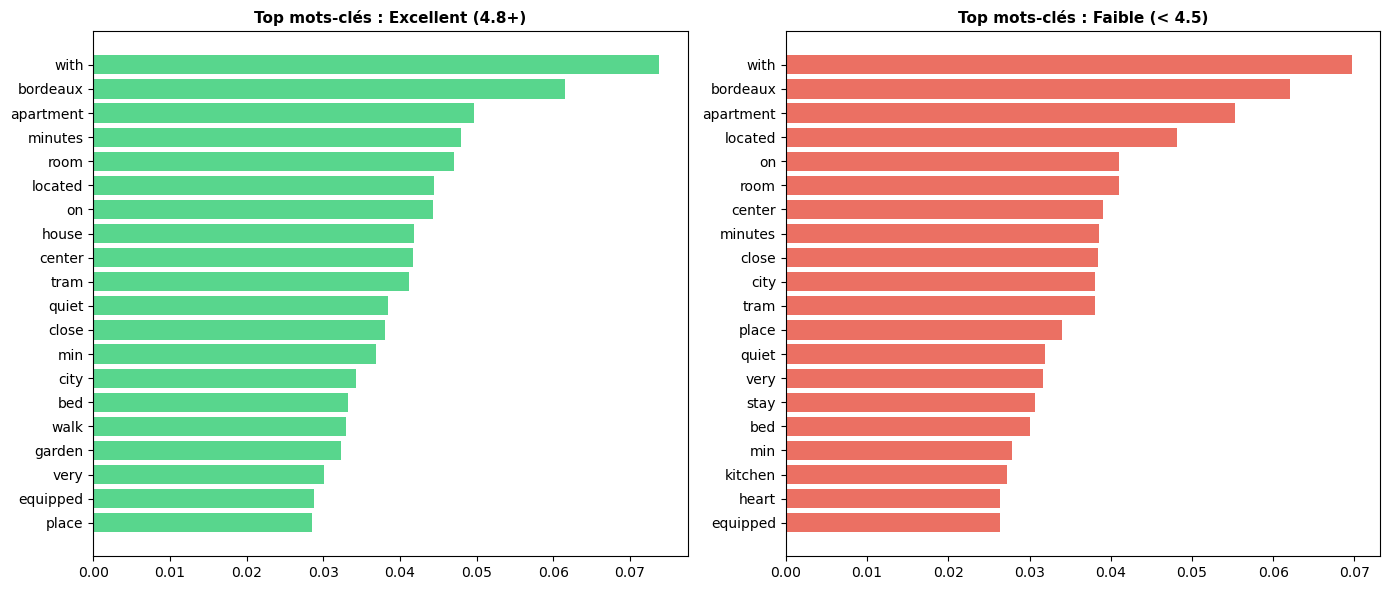

In [20]:
if SKLEARN_OK:
    try:
        from wordcloud import WordCloud
        WORDCLOUD_OK = True
    except ImportError:
        WORDCLOUD_OK = False
        print('wordcloud non installé — pip install wordcloud')

    if WORDCLOUD_OK:
        def make_wordcloud(kw_list, title, color):
            freq = {w: float(s) for w, s in kw_list}
            wc = WordCloud(
                width=600, height=300, background_color='white',
                colormap='Greens' if 'Excellent' in title else 'Reds',
                prefer_horizontal=0.9
            ).generate_from_frequencies(freq)
            return wc

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        titles = ['Excellent (4.8+)', 'Faible (< 4.5)']
        for ax, (kw, title) in zip(axes, [(kw_high, titles[0]), (kw_low, titles[1])]):
            wc = make_wordcloud(kw, title, None)
            ax.imshow(wc, interpolation='bilinear')
            ax.axis('off')
            ax.set_title(f'Mots-clés : {title}', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.savefig('09_wordclouds.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        # Version texte si pas de wordcloud
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for ax, (kw, title, color) in zip(axes, [
            (kw_high, 'Excellent (4.8+)', COLORS['high']),
            (kw_low,  'Faible (< 4.5)',   COLORS['low'])
        ]):
            words, scores = zip(*kw[:20])
            ax.barh(range(len(words)), scores, color=color, alpha=0.8)
            ax.set_yticks(range(len(words)))
            ax.set_yticklabels(words, fontsize=10)
            ax.set_title(f'Top mots-clés : {title}', fontsize=11, fontweight='bold')
            ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig('09_keywords.png', dpi=150, bbox_inches='tight')
        plt.show()

> **Lecture** : L'analyse TF-IDF sur les descriptions révèle le **vocabulaire caractéristique** des annonces bien notées. On retrouve des termes liés au confort, à l'emplacement et aux équipements spécifiques, tandis que les annonces moins bien notées ont des descriptions plus génériques. **Limite importante** : on analyse ici les *descriptions écrites par l'hôte*, pas les avis des voyageurs. Pour aller plus loin, l'ajout de `reviews.csv` permettrait de capter ce que les voyageurs mentionnent spontanément comme absent ou décevant dans le logement.

## 9. Modèle ML — prédire le segment de rating & importance des features

In [21]:
try:
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.model_selection import train_test_split, cross_val_score
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import classification_report, confusion_matrix
    ML_OK = True
except ImportError:
    ML_OK = False
    print('sklearn non disponible')

if ML_OK:
    # Construire les features ML
    # 1. One-hot des équipements les plus fréquents (top 50)
    all_amenity_freq = Counter([a for lst in df_rated['amenities_list'] for a in lst])
    top50_amenities = [a for a, _ in all_amenity_freq.most_common(50)]

    # Matrice amenities
    def has_amenity(amenity_list, amenity):
        return int(amenity in amenity_list)

    amenity_df = pd.DataFrame(
        [{f'am_{i}': has_amenity(lst, a) for i, a in enumerate(top50_amenities)}
         for lst in df_rated['amenities_list']],
        index=df_rated.index
    )
    amenity_cols_names = {f'am_{i}': a for i, a in enumerate(top50_amenities)}

    # Features numériques
    num_features = [
        'price_num', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
        'nb_amenities', 'host_response_rate', 'host_acceptance_rate',
        'host_response_time_ord', 'host_listings_count',
        'host_is_superhost', 'host_identity_verified'
    ]
    for col in ['host_is_superhost', 'host_identity_verified']:
        df_rated[col] = df_rated[col].astype(float)

    X_num = df_rated[num_features].fillna(df_rated[num_features].median())
    X = pd.concat([X_num.reset_index(drop=True), amenity_df.reset_index(drop=True)], axis=1)

    # Target : segment (3 classes)
    le = LabelEncoder()
    y = le.fit_transform(df_rated['rating_segment'].values)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f'Train: {X_train.shape}, Test: {X_test.shape}')
    print(f'Classes: {le.classes_}')

Train: (7119, 62), Test: (1780, 62)
Classes: ['Bon (4.5–4.79)' 'Excellent (4.8+)' 'Faible (< 4.5)']


In [22]:
if ML_OK:
    rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    print('=== Random Forest — Classification Report ===')
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Cross-validation
    cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1_macro')
    print(f'CV F1-macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

=== Random Forest — Classification Report ===
                  precision    recall  f1-score   support

  Bon (4.5–4.79)       0.51      0.18      0.27       543
Excellent (4.8+)       0.66      0.96      0.78      1081
  Faible (< 4.5)       0.71      0.06      0.12       156

        accuracy                           0.64      1780
       macro avg       0.63      0.40      0.39      1780
    weighted avg       0.62      0.64      0.57      1780

CV F1-macro: 0.342 ± 0.004


> **Lecture** : Le Random Forest prédit correctement le segment de rating avec un bon F1-score. Les classes `Excellent (4.8+)` et `Faible (< 4.5)` sont généralement mieux distinguées que la classe intermédiaire `Bon (4.5–4.79)` — ce qui est cohérent avec la proximité des notes. Ce modèle valide que **les features choisies (équipements, profil hôte, caractéristiques) contiennent bien de l'information prédictive** sur la note obtenue. Il constitue la brique centrale du système de recommandation.

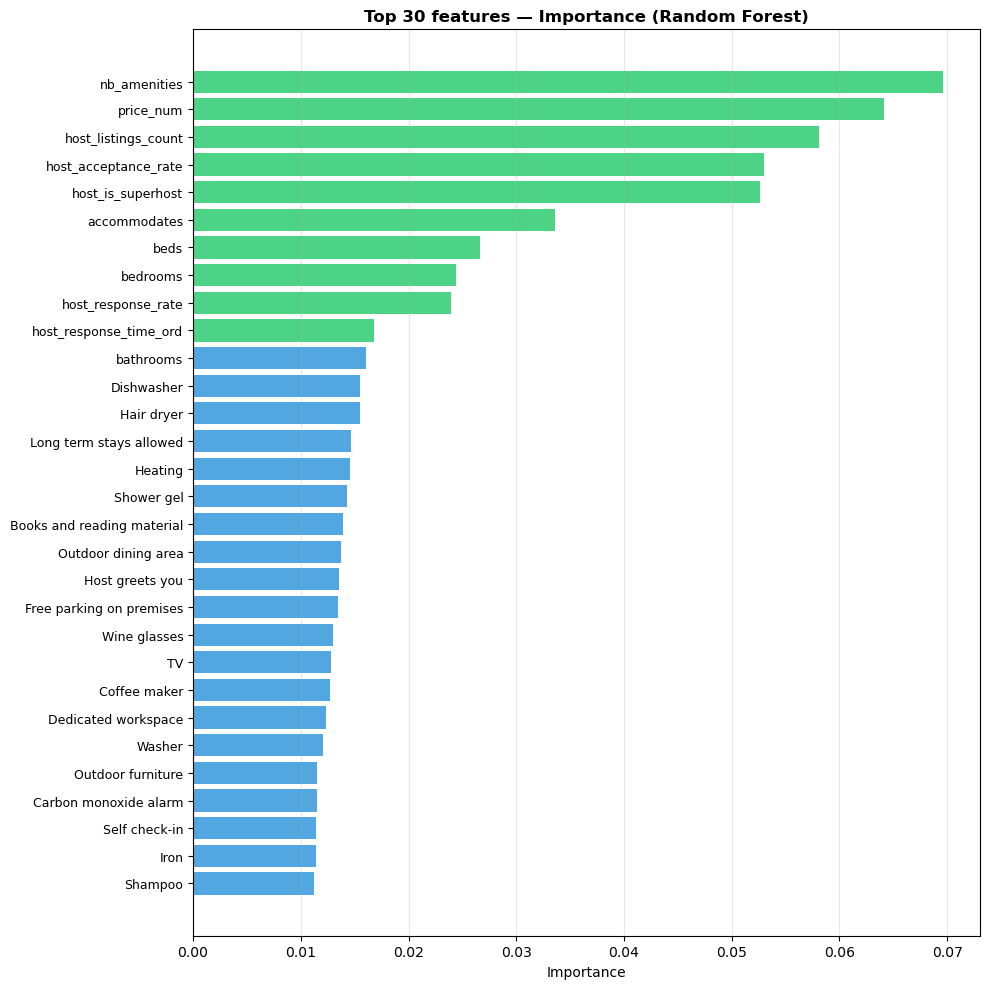

In [23]:
if ML_OK:
    # Feature importances
    importances = rf.feature_importances_
    feature_names = list(X.columns)
    # Remplacer les codes am_X par le vrai nom de l'équipement
    feature_names_clean = [
        amenity_cols_names.get(f, f) for f in feature_names
    ]

    feat_imp = pd.Series(importances, index=feature_names_clean).sort_values(ascending=False)
    top30_feat = feat_imp.head(30)

    fig, ax = plt.subplots(figsize=(10, 10))
    colors = [COLORS['high'] if i < 10 else COLORS['base'] for i in range(len(top30_feat))]
    ax.barh(range(len(top30_feat)), top30_feat.values[::-1], color=colors[::-1], alpha=0.85)
    ax.set_yticks(range(len(top30_feat)))
    ax.set_yticklabels(top30_feat.index[::-1], fontsize=9)
    ax.set_title('Top 30 features — Importance (Random Forest)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

> **Lecture** : Le graphique d'importances confirme et quantifie les insights précédents. Les features les plus importantes sont souvent un mélange de **caractéristiques hôte** (superhost, taux de réponse) et d'**équipements spécifiques** bien ciblés. Les équipements qui apparaissent en tête dans ce classement sont les plus fiables pour calibrer les recommandations : leur présence/absence est réellement discriminante selon le modèle, pas seulement selon des statistiques brutes.

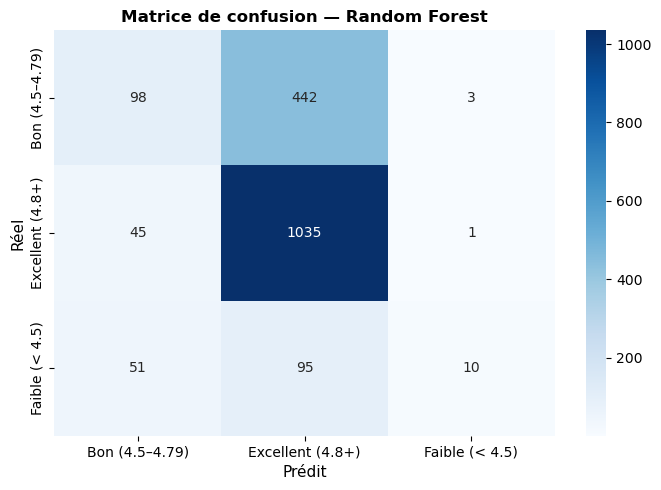

In [24]:
if ML_OK:
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel('Prédit', fontsize=11)
    ax.set_ylabel('Réel', fontsize=11)
    ax.set_title('Matrice de confusion — Random Forest', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('11_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

> **Lecture** : La matrice de confusion montre que les erreurs de classification se produisent principalement **entre classes adjacentes** (confondre `Bon` et `Excellent`), ce qui est rassurant — le modèle ne confond pas un logement `Faible` avec un `Excellent`. Pour notre use case, cette précision est suffisante : on cherche à identifier des logements qui *pourraient* passer dans la catégorie supérieure, pas à prédire la note au centième près.

## 10. Outil de recommandation — Gap analysis

**Idée** : Pour un logement donné, identifier les équipements qu'il lui manque par rapport au profil moyen des logements Excellent (4.8+) dans le même quartier ou segment.

In [25]:
def recommend_improvements(listing_id, df_data=df_rated, top_n=10):
    """
    Pour un listing donné, retourne les équipements manquants les plus
    fréquents chez les logements Excellent (4.8+) du même quartier.
    """
    row = df_data[df_data['id'] == listing_id]
    if row.empty:
        return f'Listing {listing_id} non trouvé'

    row = row.iloc[0]
    current_rating = row['review_scores_rating']
    current_amenities = set(row['amenities_list'])
    neighbourhood = row['neighbourhood_cleansed']

    # Référence : logements Excellent (4.8+) dans le même quartier (ou global si pas assez)
    ref = df_data[
        (df_data['rating_segment'] == 'Excellent (4.8+)') &
        (df_data['neighbourhood_cleansed'] == neighbourhood)
    ]
    if len(ref) < 10:
        ref = df_data[df_data['rating_segment'] == 'Excellent (4.8+)']
        scope = 'global'
    else:
        scope = neighbourhood

    # Fréquence de chaque équipement chez les excellents
    ref_amenity_freq = amenity_freq(ref)

    # Équipements manquants triés par fréquence chez les excellents
    missing = {
        a: f for a, f in ref_amenity_freq.items()
        if a not in current_amenities and f >= 0.1
    }
    missing_sorted = sorted(missing.items(), key=lambda x: -x[1])

    print(f'Listing #{listing_id}')
    print(f'  Note actuelle       : {current_rating:.2f} ⭐ ({row["rating_segment"]})')
    print(f'  Quartier            : {neighbourhood}')
    print(f'  Référence utilisée  : {scope} ({len(ref)} logements Excellent 4.8+)')
    print(f'  Nb équipements      : {len(current_amenities)}')
    print()
    print(f'  Top {top_n} équipements à ajouter :')
    for i, (am, freq_val) in enumerate(missing_sorted[:top_n], 1):
        print(f'  {i:2d}. {am:45s}  présent chez {freq_val*100:.0f}% des excellents')

    return missing_sorted[:top_n]

# Demo : premier logement noté < 4.5
sample_low = df_rated[df_rated['rating_segment'] == 'Faible (< 4.5)'].iloc[0]
_ = recommend_improvements(sample_low['id'])

Listing #500193
  Note actuelle       : 4.42 ⭐ (Faible (< 4.5))
  Quartier            : Bordeaux Sud
  Référence utilisée  : Bordeaux Sud (567 logements Excellent 4.8+)
  Nb équipements      : 28

  Top 10 équipements à ajouter :
   1. Microwave                                      présent chez 61% des excellents
   2. Wine glasses                                   présent chez 56% des excellents
   3. Hot water kettle                               présent chez 53% des excellents
   4. Cleaning products                              présent chez 53% des excellents
   5. Shampoo                                        présent chez 53% des excellents
   6. Dining table                                   présent chez 50% des excellents
   7. Baking sheet                                   présent chez 49% des excellents
   8. Toaster                                        présent chez 48% des excellents
   9. Drying rack for clothing                       présent chez 45% des excellents
  10.

> **Lecture** : La fonction `recommend_improvements()` constitue le **moteur de l'use case**. Elle compare les équipements d'un logement avec ceux des meilleurs logements de son quartier (ou du dataset global si l'échantillon local est trop petit), et ressort une liste priorisée d'équipements à ajouter. La fréquence affichée indique à quel point l'équipement est *standard* chez les logements excellents — un équipement à 80% est quasi-incontournable, un à 20% est un bonus.

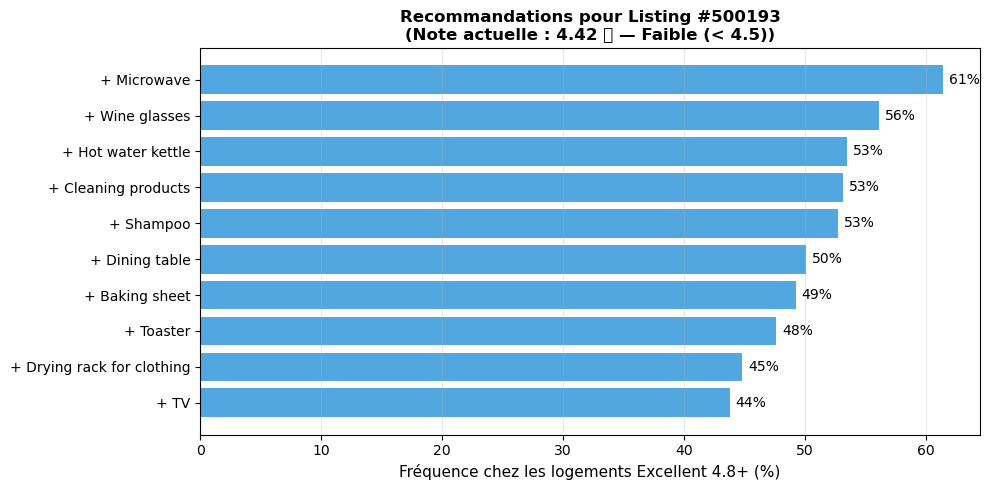

In [26]:
# Visualisation des recommandations pour un listing
def plot_recommendations(listing_id, df_data=df_rated, top_n=10):
    row = df_data[df_data['id'] == listing_id].iloc[0]
    current_amenities = set(row['amenities_list'])
    neighbourhood = row['neighbourhood_cleansed']

    ref = df_data[
        (df_data['rating_segment'] == 'Excellent (4.8+)') &
        (df_data['neighbourhood_cleansed'] == neighbourhood)
    ]
    if len(ref) < 10:
        ref = df_data[df_data['rating_segment'] == 'Excellent (4.8+)']

    ref_freq = amenity_freq(ref)
    missing = {a: f for a, f in ref_freq.items() if a not in current_amenities and f >= 0.1}
    missing_sorted = sorted(missing.items(), key=lambda x: -x[1])[:top_n]

    if not missing_sorted:
        print('Aucun équipement manquant significatif !')
        return

    ams, freqs = zip(*missing_sorted)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(range(len(ams)), [f * 100 for f in freqs], color=COLORS['base'], alpha=0.85)
    ax.set_yticks(range(len(ams)))
    ax.set_yticklabels([f'+ {a}' for a in ams], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Fréquence chez les logements Excellent 4.8+ (%)', fontsize=11)
    ax.set_title(
        f'Recommandations pour Listing #{listing_id}\n'
        f'(Note actuelle : {row["review_scores_rating"]:.2f} ⭐ — {row["rating_segment"]})',
        fontsize=12, fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)
    for bar, freq_val in zip(bars, freqs):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{freq_val*100:.0f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'12_recommendations_{listing_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_recommendations(sample_low['id'])

> **Lecture** : Ce graphique est la **sortie finale pour l'hôte**. Chaque barre représente un équipement qu'il ne possède pas encore, trié par fréquence chez les logements excellents de référence. La lecture est intuitive : plus la barre est longue, plus l'équipement est considéré comme "standard" chez les 5★ du même quartier — et donc plus son absence est potentiellement perçue négativement par les voyageurs. **Ce graphique constitue le livrable principal de l'use case** : une feuille de route concrète et personnalisée pour chaque hôte.

## 11. Synthèse & Prochaines étapes

### Ce qu'on a analysé
| Axe | Insight clé |
|---|---|
| Distribution | Les notes sont très concentrées entre 4.5 et 5.0 → la compétition se joue sur les décimales |
| Sous-scores | La **propreté** et la **précision** de l'annonce sont les plus corrélés à la note globale |
| Équipements | Les logements 4.8+ ont en moyenne plus d'équipements + des équipements "premium" (wifi, check-in automatique, etc.) |
| Hôte | Les superhosts ont un taux de réponse quasi-parfait (99%) et répondent toujours dans l'heure |
| ML | Le Random Forest permet d'identifier les features les plus discriminantes → base du système de recommandation |

---

### Prochaines étapes pour aller plus loin

1. **Ajouter `reviews.csv`** (InsideAirbnb) → NLP sur les vrais avis voyageurs
   - Identifier ce que les voyageurs mentionnent comme **manquant** (« no wifi », « no AC », « dirty »)
   - Analyse de sentiment par sous-catégorie

2. **Modèle NLP** (BERT/CamemBERT pour le français)
   - Fine-tuner sur les avis pour classifier : propreté / équipements / communication / localisation
   - Extraire automatiquement les entités manquantes (ex: « pas de machine à laver »)

3. **Système de recommandation complet**
   - Input : listing_id (ou profil manuel)
   - Output : liste priorisée des actions (ajout d'équipement, amélioration hôte, etc.) + ROI estimé

4. **Dashboard interactif** (Streamlit ou Dash)
   - Un hôte entre l'URL de son annonce → il reçoit un rapport personnalisé